In [2]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

In [3]:
# Load ML models
ml_models = joblib.load("ml_models.joblib")

# Load ANN
ann = tf.keras.models.load_model("keras_ann.keras")

# Load ANN preprocessing
ann_preprocessor = joblib.load("ann_preprocessor.joblib")

# Load model comparison
comparison = pd.read_csv("model_comparison.csv")

print("Models loaded successfully.")
print("ML models:", list(ml_models.keys()))

Models loaded successfully.
ML models: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


In [4]:
customer = pd.DataFrame([{
    "CreditScore": 650,
    "Geography": "France",
    "Gender": "Male",
    "Age": 40,
    "Tenure": 5,
    "Balance": 100000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 1,
    "EstimatedSalary": 60000
}])

customer

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,650,France,Male,40,5,100000,2,1,1,60000


In [7]:
# Feature engineering — must exactly match training

customer["BalanceSalaryRatio"] = (
    customer["Balance"] / customer["EstimatedSalary"]
)

customer["TenureByAge"] = (
    customer["Tenure"] / customer["Age"]
)

customer["HasZeroBalance"] = (
    customer["Balance"] == 0
).astype(int)

customer["BalancePerProduct"] = (
    customer["Balance"] / customer["NumOfProducts"]
)

customer["SalaryPerProduct"] = (
    customer["EstimatedSalary"] / customer["NumOfProducts"]
)

customer["IsSenior"] = (
    customer["Age"] >= 50
).astype(int)

customer

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureByAge,HasZeroBalance,BalancePerProduct,SalaryPerProduct,IsSenior
0,650,France,Male,40,5,100000,2,1,1,60000,1.666667,0.125,0,50000.0,30000.0,0


In [8]:
prediction_results = []

for name, model in ml_models.items():
    probability = model.predict_proba(customer)[0, 1]
    prediction = int(probability >= 0.5)

    prediction_results.append({
        "Model": name,
        "Type": "Traditional ML",
        "Churn Probability": probability,
        "Prediction": "Churn" if prediction == 1 else "No Churn"
    })

In [9]:
customer_ann = ann_preprocessor.transform(customer)

ann_probability = ann.predict(
    customer_ann,
    verbose=0
).ravel()[0]

ann_prediction = int(ann_probability >= 0.5)

prediction_results.append({
    "Model": "Keras ANN",
    "Type": "Deep Learning",
    "Churn Probability": ann_probability,
    "Prediction": "Churn" if ann_prediction == 1 else "No Churn"
})

In [10]:
prediction_comparison = pd.DataFrame(prediction_results)

prediction_comparison["Churn Probability"] = (
    prediction_comparison["Churn Probability"] * 100
).round(2)

prediction_comparison

,Model,Type,Churn Probability,Prediction
0,Logistic Regression,Traditional ML,26.70,No Churn
1,Random Forest,Traditional ML,21.64,No Churn
2,XGBoost,Traditional ML,4.91,No Churn
3,LightGBM,Traditional ML,17.21,No Churn
4,Keras ANN,Deep Learning,5.68,No Churn


In [11]:
comparison

,Model,Type,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,Traditional ML,0.8680,0.791837,0.476658,0.595092,0.869803
1,Keras ANN,Deep Learning,0.8655,0.765385,0.488943,0.596702,0.867556
2,LightGBM,Traditional ML,0.8140,0.530541,0.746929,0.620408,0.867053
3,Random Forest,Traditional ML,0.8165,0.536232,0.727273,0.617310,0.864138
4,Logistic Regression,Traditional ML,0.7185,0.398438,0.751843,0.520851,0.791980


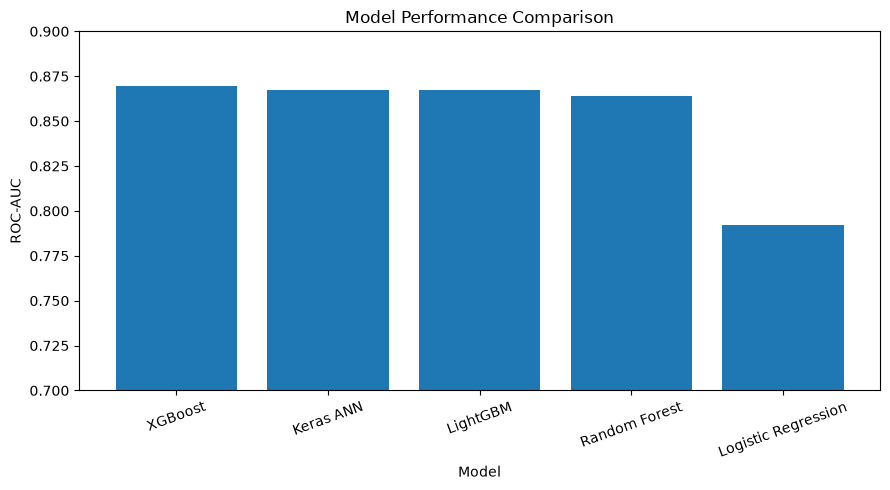

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["ROC-AUC"]
)

plt.ylim(0.7, 0.9)
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [14]:
df = pd.read_csv("Churn_Modelling.csv")

df = df.drop(
    columns=["RowNumber", "CustomerId", "Surname"]
)

# Same feature engineering used during training
df["BalanceSalaryRatio"] = (
    df["Balance"] / df["EstimatedSalary"]
)

df["TenureByAge"] = (
    df["Tenure"] / df["Age"]
)

df["HasZeroBalance"] = (
    df["Balance"] == 0
).astype(int)

df["BalancePerProduct"] = (
    df["Balance"] / df["NumOfProducts"]
)

df["SalaryPerProduct"] = (
    df["EstimatedSalary"] / df["NumOfProducts"]
)

df["IsSenior"] = (
    df["Age"] >= 50
).astype(int)

X = df.drop(columns="Exited")
y = df["Exited"]

print(X.shape)
print(y.shape)

(10000, 16)
(10000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 8000
Test samples: 2000


In [16]:
def find_best_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        probabilities
    )

    f1_scores = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )

    best_index = np.argmax(f1_scores)

    return float(thresholds[best_index])

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

optimized_thresholds = {}

In [18]:
for name, model in ml_models.items():

    print(f"Optimizing threshold for {name}...")

    oof_probability = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold = find_best_threshold(
        y_train,
        oof_probability
    )

    optimized_thresholds[name] = threshold

    print(
        f"{name}: optimal threshold = {threshold:.4f}"
    )

Optimizing threshold for Logistic Regression...
Logistic Regression: optimal threshold = 0.5756
Optimizing threshold for Random Forest...
Random Forest: optimal threshold = 0.5536
Optimizing threshold for XGBoost...
XGBoost: optimal threshold = 0.3233
Optimizing threshold for LightGBM...
LightGBM: optimal threshold = 0.5969


In [19]:
X_train_ann = ann_preprocessor.transform(X_train)

ann_train_probability = ann.predict(
    X_train_ann,
    verbose=0
).ravel()

In [20]:
ann_threshold = find_best_threshold(
    y_train,
    ann_train_probability
)

optimized_thresholds["Keras ANN"] = ann_threshold

print(
    f"Keras ANN: optimal threshold = {ann_threshold:.4f}"
)

Keras ANN: optimal threshold = 0.2970


In [21]:
threshold_table = pd.DataFrame(
    optimized_thresholds.items(),
    columns=["Model", "Optimal Threshold"]
)

threshold_table

,Model,Optimal Threshold
0,Logistic Regression,0.575642
1,Random Forest,0.553554
2,XGBoost,0.323315
3,LightGBM,0.596866
4,Keras ANN,0.297042


In [22]:
threshold_results = []

for name, model in ml_models.items():

    probability = model.predict_proba(
        X_test
    )[:, 1]

    threshold = optimized_thresholds[name]

    prediction = (
        probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test, prediction
        ),
        "Precision": precision_score(
            y_test, prediction
        ),
        "Recall": recall_score(
            y_test, prediction
        ),
        "F1": f1_score(
            y_test, prediction
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probability
        )
    })

In [23]:
X_test_ann = ann_preprocessor.transform(X_test)

ann_test_probability = ann.predict(
    X_test_ann,
    verbose=0
).ravel()

ann_test_threshold = optimized_thresholds["Keras ANN"]

ann_test_prediction = (
    ann_test_probability >= ann_test_threshold
).astype(int)

threshold_results.append({
    "Model": "Keras ANN",
    "Threshold": ann_test_threshold,
    "Accuracy": accuracy_score(
        y_test,
        ann_test_prediction
    ),
    "Precision": precision_score(
        y_test,
        ann_test_prediction
    ),
    "Recall": recall_score(
        y_test,
        ann_test_prediction
    ),
    "F1": f1_score(
        y_test,
        ann_test_prediction
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        ann_test_probability
    )
})

In [24]:
optimized_comparison = pd.DataFrame(
    threshold_results
)

optimized_comparison = optimized_comparison.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

optimized_comparison.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.3233,0.8535,0.6411,0.6364,0.6387,0.8698
1,Keras ANN,0.2970,0.8405,0.5921,0.6953,0.6395,0.8676
2,LightGBM,0.5969,0.8430,0.6022,0.6732,0.6357,0.8671
3,Random Forest,0.5536,0.8425,0.5996,0.6806,0.6375,0.8641
4,Logistic Regression,0.5756,0.7615,0.4384,0.6118,0.5108,0.7920


In [25]:
joblib.dump(
    optimized_thresholds,
    "model_thresholds.joblib"
)

optimized_comparison.to_csv(
    "optimized_model_comparison.csv",
    index=False
)

print("Thresholds and comparison saved.")

Thresholds and comparison saved.


In [26]:
import os

print(
    os.path.exists("model_thresholds.joblib")
)

print(
    os.path.exists("optimized_model_comparison.csv")
)

True
True


In [32]:
from sklearn.inspection import permutation_importance

In [33]:
feature_importance_results = {}

for name, model in ml_models.items():

    print(f"Calculating feature importance for {name}...")

    importance = permutation_importance(
        model,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": importance.importances_mean,
        "Std": importance.importances_std
    }).sort_values(
        "Importance",
        ascending=False
    )

    feature_importance_results[name] = importance_df

print("Feature importance calculated.")

Calculating feature importance for Logistic Regression...
Calculating feature importance for Random Forest...
Calculating feature importance for XGBoost...
Calculating feature importance for LightGBM...
Feature importance calculated.


In [34]:
feature_importance_results["XGBoost"]

,Feature,Importance,Std
3,Age,0.116377,0.005950
6,NumOfProducts,0.103993,0.009884
8,IsActiveMember,0.032302,0.003620
1,Geography,0.018732,0.001642
13,BalancePerProduct,0.008623,0.001489
2,Gender,0.008148,0.001369
5,Balance,0.006791,0.000976
10,BalanceSalaryRatio,0.005193,0.001344
0,CreditScore,0.001314,0.000626
12,HasZeroBalance,0.000445,0.000348


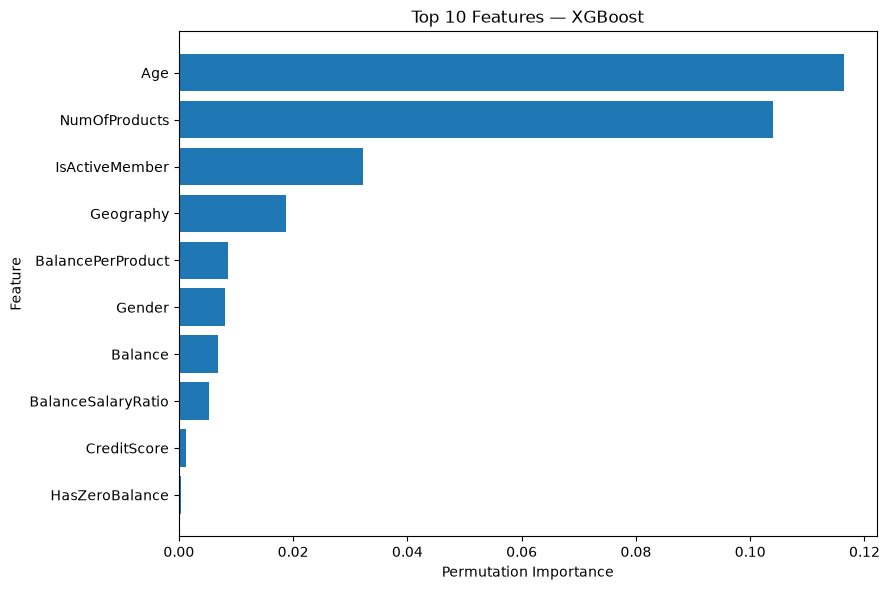

In [35]:
import matplotlib.pyplot as plt

xgb_importance = feature_importance_results["XGBoost"].copy()

xgb_importance = xgb_importance.head(10)

plt.figure(figsize=(9, 6))

plt.barh(
    xgb_importance["Feature"][::-1],
    xgb_importance["Importance"][::-1]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — XGBoost")
plt.tight_layout()
plt.show()

In [36]:
xgb_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [37]:
for name, importance_df in feature_importance_results.items():

    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)

    display(
        importance_df.head(10)
    )


Logistic Regression


,Feature,Importance,Std
14,SalaryPerProduct,0.120054,0.011628
9,EstimatedSalary,0.097690,0.010545
3,Age,0.082934,0.006058
8,IsActiveMember,0.046392,0.005660
11,TenureByAge,0.041045,0.003772
6,NumOfProducts,0.026760,0.004387
2,Gender,0.017846,0.002651
1,Geography,0.016946,0.003374
4,Tenure,0.012993,0.002559
5,Balance,0.010423,0.002812



Random Forest


,Feature,Importance,Std
6,NumOfProducts,0.104216,0.009670
3,Age,0.084161,0.004252
8,IsActiveMember,0.029941,0.003443
1,Geography,0.024793,0.002498
13,BalancePerProduct,0.007282,0.001535
15,IsSenior,0.006782,0.002675
5,Balance,0.004855,0.001576
2,Gender,0.003940,0.001101
10,BalanceSalaryRatio,0.003429,0.001621
12,HasZeroBalance,0.000533,0.000590



XGBoost


,Feature,Importance,Std
3,Age,0.116377,0.005950
6,NumOfProducts,0.103993,0.009884
8,IsActiveMember,0.032302,0.003620
1,Geography,0.018732,0.001642
13,BalancePerProduct,0.008623,0.001489
2,Gender,0.008148,0.001369
5,Balance,0.006791,0.000976
10,BalanceSalaryRatio,0.005193,0.001344
0,CreditScore,0.001314,0.000626
12,HasZeroBalance,0.000445,0.000348



LightGBM


,Feature,Importance,Std
6,NumOfProducts,0.110678,0.010189
3,Age,0.099067,0.004823
8,IsActiveMember,0.033349,0.003545
1,Geography,0.025175,0.002753
5,Balance,0.013479,0.002284
2,Gender,0.008495,0.001880
13,BalancePerProduct,0.005895,0.000933
10,BalanceSalaryRatio,0.005690,0.002077
15,IsSenior,0.001202,0.000846
12,HasZeroBalance,0.000065,0.000095


In [38]:
top_features = feature_importance_results["XGBoost"].head(10).copy()

top_features

,Feature,Importance,Std
3,Age,0.116377,0.005950
6,NumOfProducts,0.103993,0.009884
8,IsActiveMember,0.032302,0.003620
1,Geography,0.018732,0.001642
13,BalancePerProduct,0.008623,0.001489
2,Gender,0.008148,0.001369
5,Balance,0.006791,0.000976
10,BalanceSalaryRatio,0.005193,0.001344
0,CreditScore,0.001314,0.000626
12,HasZeroBalance,0.000445,0.000348


In [39]:
top_features.to_csv(
    "top_churn_features.csv",
    index=False
)

In [40]:
xgb_test_probability = ml_models["XGBoost"].predict_proba(
    X_test
)[:, 1]

In [41]:
test_risk = pd.DataFrame({
    "Churn Probability": xgb_test_probability,
    "Actual Churn": y_test.values
})

test_risk["Risk Segment"] = pd.cut(
    test_risk["Churn Probability"],
    bins=[-0.01, 0.30, 0.60, 1.01],
    labels=["Low", "Medium", "High"]
)

test_risk.head()

,Churn Probability,Actual Churn,Risk Segment
0,0.024392,0,Low
1,0.076084,0,Low
2,0.044750,0,Low
3,0.041368,0,Low
4,0.104539,0,Low


In [42]:
risk_summary = (
    test_risk
    .groupby("Risk Segment", observed=True)
    .agg(
        Customers=("Actual Churn", "size"),
        Actual_Churn_Rate=("Actual Churn", "mean")
    )
    .reset_index()
)

risk_summary["Actual_Churn_Rate"] = (
    risk_summary["Actual_Churn_Rate"] * 100
).round(2)

risk_summary

,Risk Segment,Customers,Actual_Churn_Rate
0,Low,1566,8.94
1,Medium,256,43.36
2,High,178,87.64


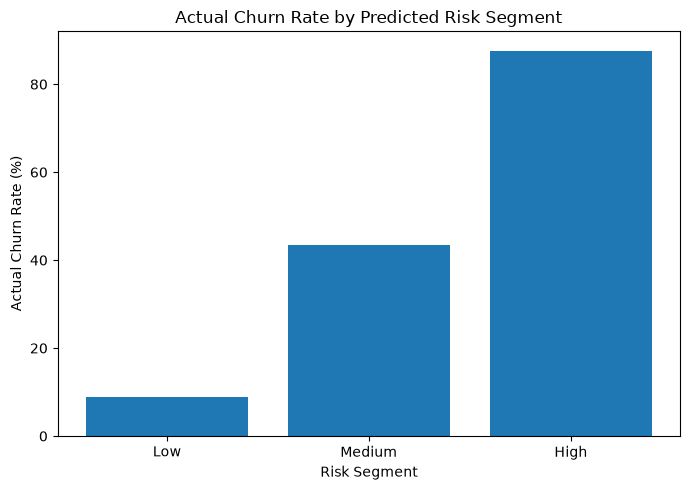

In [43]:
plt.figure(figsize=(7, 5))

plt.bar(
    risk_summary["Risk Segment"],
    risk_summary["Actual_Churn_Rate"]
)

plt.xlabel("Risk Segment")
plt.ylabel("Actual Churn Rate (%)")
plt.title("Actual Churn Rate by Predicted Risk Segment")

plt.tight_layout()
plt.show()

In [44]:
risk_summary.to_csv(
    "risk_segmentation.csv",
    index=False
)

print("Risk segmentation saved.")

Risk segmentation saved.


In [27]:
def get_risk_segment(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

In [28]:
prediction_comparison = pd.DataFrame(prediction_results)

prediction_comparison["Churn Probability"] = (
    prediction_comparison["Churn Probability"] * 100
).round(2)

prediction_comparison["Risk Segment"] = (
    prediction_comparison["Churn Probability"]
    .apply(lambda x: get_risk_segment(x / 100))
)

prediction_comparison

,Model,Type,Churn Probability,Prediction,Risk Segment
0,Logistic Regression,Traditional ML,26.70,No Churn,Low
1,Random Forest,Traditional ML,21.64,No Churn,Low
2,XGBoost,Traditional ML,4.91,No Churn,Low
3,LightGBM,Traditional ML,17.21,No Churn,Low
4,Keras ANN,Deep Learning,5.68,No Churn,Low


In [29]:
def get_action(risk):
    if risk == "High":
        return "Immediate retention action"
    elif risk == "Medium":
        return "Monitor and engage"
    else:
        return "Routine monitoring"

In [30]:
prediction_comparison["Recommended Action"] = (
    prediction_comparison["Risk Segment"]
    .apply(get_action)
)

prediction_comparison

,Model,Type,Churn Probability,Prediction,Risk Segment,Recommended Action
0,Logistic Regression,Traditional ML,26.70,No Churn,Low,Routine monitoring
1,Random Forest,Traditional ML,21.64,No Churn,Low,Routine monitoring
2,XGBoost,Traditional ML,4.91,No Churn,Low,Routine monitoring
3,LightGBM,Traditional ML,17.21,No Churn,Low,Routine monitoring
4,Keras ANN,Deep Learning,5.68,No Churn,Low,Routine monitoring


In [31]:
prediction_comparison.to_csv(
    "customer_prediction_result.csv",
    index=False
)

print("Prediction result saved.")

Prediction result saved.
